In [33]:
from build.models.main import *
from build import Genome
from build.util.datetime import eta, clock

from numpy import ndarray as CPUArray

import torch
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
# import matplotlib.
import numpy as np

In [34]:
torch.set_printoptions(threshold=10)

In [35]:
device = 'cuda'
dtype  = torch.float64

In [36]:
genomes = {key: Genome(key) for key in range(1, 2)}

In [37]:
batch_size  = 8
seq_len     = 32
input_dims  = 1
output_dims = 1
embedding   = 32
heads       = 2
layers      = 1
differential = False
bias        = False

In [38]:
records = 10

In [39]:
upper   = 1000
divider = upper + seq_len

In [40]:
def create(genomes_num: int, low: int, high: int, records, seq_len: int, size: int, inv=True):
    source = torch.stack([
        torch.stack([
            torch.arange(i, i+(size if not inv else seq_len)) for i in torch.randint(low, high, (seq_len if not inv else size,))
        ]) for _ in range(records)
    ])
    if inv:
        source = source.mT
    inp = source
    s = inp.shape[-2]
    # out = inp.clone()[..., s-1:s, :] + 1
    out = source + 1
    return inp.to(device, dtype).unsqueeze(0).expand(genomes_num, *inp.shape) / divider, \
           out.to(device, dtype).unsqueeze(0).expand(genomes_num, *out.shape) / divider

In [41]:
train_inp, train_out = create(len(genomes), 0, upper, records, seq_len, output_dims, True)
eval_inp, eval_out   = create(len(genomes), 0, upper, records, seq_len, output_dims, True)

In [42]:
train_inp.shape, train_out.shape

(torch.Size([1, 10, 32, 1]), torch.Size([1, 10, 32, 1]))

In [43]:
train_inp.mT

tensor([[[[0.3391, 0.3401, 0.3411,  ..., 0.3672, 0.3682, 0.3692]],

         [[0.8198, 0.8207, 0.8217,  ..., 0.8479, 0.8488, 0.8498]],

         [[0.6328, 0.6337, 0.6347,  ..., 0.6609, 0.6618, 0.6628]],

         ...,

         [[0.2112, 0.2122, 0.2132,  ..., 0.2393, 0.2403, 0.2413]],

         [[0.0601, 0.0610, 0.0620,  ..., 0.0882, 0.0891, 0.0901]],

         [[0.2364, 0.2374, 0.2384,  ..., 0.2645, 0.2655, 0.2665]]]],
       device='cuda:0', dtype=torch.float64)

In [44]:
train_out.mT

tensor([[[[0.3401, 0.3411, 0.3421,  ..., 0.3682, 0.3692, 0.3702]],

         [[0.8207, 0.8217, 0.8227,  ..., 0.8488, 0.8498, 0.8508]],

         [[0.6337, 0.6347, 0.6357,  ..., 0.6618, 0.6628, 0.6638]],

         ...,

         [[0.2122, 0.2132, 0.2141,  ..., 0.2403, 0.2413, 0.2422]],

         [[0.0610, 0.0620, 0.0630,  ..., 0.0891, 0.0901, 0.0911]],

         [[0.2374, 0.2384, 0.2393,  ..., 0.2655, 0.2665, 0.2674]]]],
       device='cuda:0', dtype=torch.float64)

In [45]:
# test_inp = torch.randn(len(genomes), records, seq_len, output_dims, device=device)
# test_out = torch.cat([test_inp[..., 1:, :], torch.randn(len(genomes), records, 1, output_dims, device=device)], -2)

In [46]:
def model_size(model: NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [47]:
constant = 2 ** np.floor(np.log2(seq_len * embedding)) // 2
constant

512.0

In [48]:
transformer = Transformer(input_dims, output_dims, embedding, seq_len, layers, heads, 1,
                          differential=differential, dropout=0.01, bias=bias,
                          constant=constant, causal_mask=True, device=device, dtype=dtype)
transformer.eval()
optimizer = optim.AdamW(transformer.parameters(), 1e-3)
transformer.update(genomes)
transformer, model_size(transformer)

(Transformer(
   (primary_activation): SiLU()
   (embedder): BufferEmbedding(
     (embedding): Linear[NeatModule](inputs=1, outputs=32, bias=False)
   )
   (encoder): BufferEncoding(
     (encoding): Linear[NeatModule](inputs=1, outputs=32, bias=False)
     (activation): SiLU()
   )
   (transformer): TransformerBase(
     (layers): ModuleList(
       (0): TransformerBlock(
         (attention): Attention(
           (query_proj): Linear[NeatModule](inputs=32, outputs=32, bias=False)
           (key_proj): Linear[NeatModule](inputs=32, outputs=16, bias=False)
           (value_proj): Linear[NeatModule](inputs=32, outputs=16, bias=False)
           (out_proj): Linear[NeatModule](inputs=32, outputs=32, bias=False)
           (rotary_embedding): RoPE()
           (softmax): Softmax(dim=-1)
           (norm): RMSNorm[NeatModule](shape=(16,), eps=1e-08, elementwise_affine=True)
         )
         (att_norm): RMSNorm[NeatModule](shape=(32,), eps=1e-08, elementwise_affine=True)
         (fee

In [49]:
# %%temit -r 10 -n 3
outputs = transformer(eval_inp[:, :6], verbose=1, get=True, single=True)
att, att_val = transformer.get_attention()
outputs.shape, att[0].size(), att[0].max(), att[0].min()


Transformer Input =>
tensor([[[[0.1492],
          [0.1502],
          [0.1512],
          ...,
          [0.1773],
          [0.1783],
          [0.1793]],

         [[0.8663],
          [0.8672],
          [0.8682],
          ...,
          [0.8944],
          [0.8953],
          [0.8963]],

         [[0.8178],
          [0.8188],
          [0.8198],
          ...,
          [0.8459],
          [0.8469],
          [0.8479]],

         [[0.1550],
          [0.1560],
          [0.1570],
          ...,
          [0.1831],
          [0.1841],
          [0.1851]],

         [[0.3314],
          [0.3324],
          [0.3333],
          ...,
          [0.3595],
          [0.3605],
          [0.3614]],

         [[0.8537],
          [0.8547],
          [0.8556],
          ...,
          [0.8818],
          [0.8828],
          [0.8837]]]], device='cuda:0', dtype=torch.float64)
	dim = torch.Size([1, 6, 32, 1])

Embedded tensor =>
tensor([[[[-0.3569,  0.2702,  0.3371,  ..., -0.0399,  0.1245,  0

(torch.Size([1, 6, 1, 1]),
 torch.Size([1, 6, 2, 1, 32]),
 tensor(0.9493, device='cuda:0', dtype=torch.float64),
 tensor(7.5215e-20, device='cuda:0', dtype=torch.float64))

In [50]:
outputs.shape

torch.Size([1, 6, 1, 1])

In [51]:
# torch.sum(torch.randn(1, 1, 4, 32, 1))

In [52]:
def normalize(tensor: Tensor):
    maximum, minimum = tensor.max(), tensor.min()
    if maximum-minimum != 0:
        return (tensor - minimum) / (maximum - minimum)
    else:
        return tensor

In [53]:
for i, att_head in enumerate(eval_out[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[155., 156., 157.,  ..., 184., 185., 186.]], device='cuda:0',
       dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[895., 896., 897.,  ..., 924., 925., 926.]], device='cuda:0',
       dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[845., 846., 847.,  ..., 874., 875., 876.]], device='cuda:0',
       dtype=torch.float64)


In [54]:
for i, att_head in enumerate(outputs[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 1])
tensor([[1668.]], device='cuda:0', dtype=torch.float64)
Record 2: torch.Size([1, 1])
tensor([[-2950.]], device='cuda:0', dtype=torch.float64)
Record 3: torch.Size([1, 1])
tensor([[-2576.]], device='cuda:0', dtype=torch.float64)


In [55]:
for a in att:
    print(a.shape)

torch.Size([1, 6, 2, 1, 32])


In [56]:
def plot_attention(attention: list[Tensor], genome_index: int, layer_index: int, records: int, randomize=False, size=(1440, 1080), inverse=False, cmap='bone_r'):
    attention: Tensor = attention[layer_index]
    g, b, heads, q, k = attention.shape
    fig, axes = plt.subplots(records, heads, figsize=(size[0]*0.01, size[1]*0.01))
    if isinstance(axes, CPUArray):
        axes = axes.flatten()
    else:
        axes = [axes]
    if inverse:
        axes = axes[::-1]
    x = 0
    if not randomize:
        indices = torch.arange(records)
    else:
        indices = torch.randperm(attention.size(1))[:records]
    for i, record in enumerate(torch.index_select(attention[genome_index], 0, indices.to(device))):
        for j, att_head in enumerate(record):
            if q == 1:
                att_head = att_head.expand(k, k)
            axes[x].imshow(att_head.float().cpu(), cmap=cmap)
            x += 1
    plt.show()
    return att_head

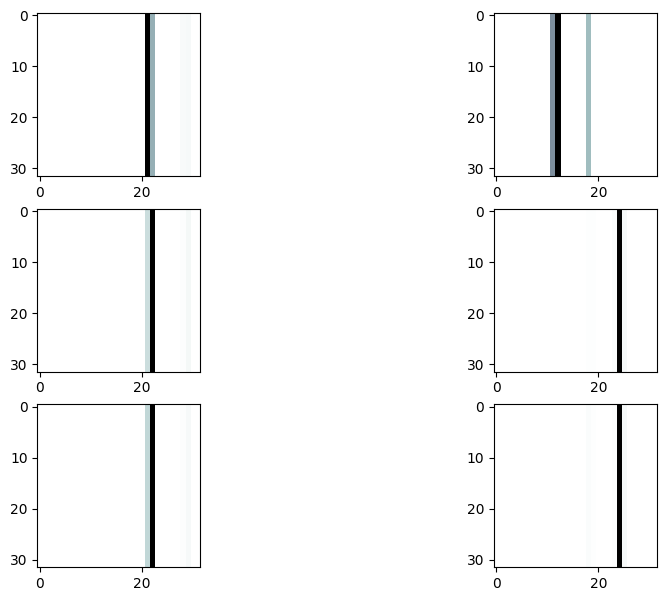

In [57]:
ah = plot_attention(att, 0, 0, 3, False, size=(1080, 720));

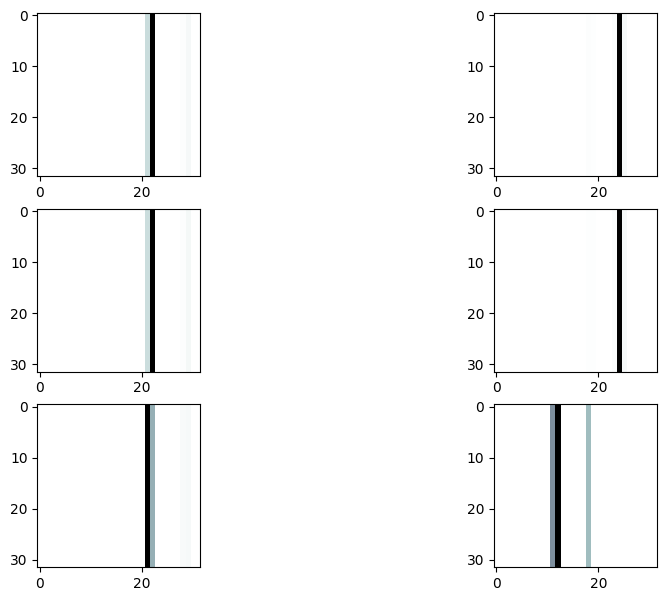

In [58]:
plot_attention(att, 0, -1, 3, True, size=(1080, 720));

In [59]:
def accuracy(prediction, target, error=0.01):
    prediction, target = prediction*divider, target*divider
    total = ((prediction >= target*(1-error)) & (prediction <= target*(1+error))) == True
    acc = (total.float().count_nonzero() / target.numel()).item()
    return np.round(acc, 4) * 100

In [60]:
accuracy(transformer(eval_inp, single=False), eval_out)

0.0

In [61]:
def train(epochs: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    # transformer.train()
    transformer.requires_gradients(True)
    # attention.causal_mask = False

    losses = []
    ts, ud, ut = clock.perf_counter(), 0, epochs
    best_loss = F.mse_loss(transformer(train_inp, single=False), train_out,)
    best_epoch = -1
    save_state = transformer.state_dict()
    for epoch in range(epochs):
        try:
            optimizer.zero_grad()
            test_actv = transformer(train_inp, single=False)
            loss = F.mse_loss(test_actv, train_out)
            loss.backward()
            optimizer.step()

            losses.append(loss.cpu().item())

            if epoch % checkpoints == 0 and loss < best_loss:
                best_loss = loss
                save_state = transformer.state_dict()
                best_epoch = epoch

            ud += 1
            eta(ts, ud, ut, f"training | loss={loss.cpu().item(): .4e} | "
                            f"best={best_loss.cpu().item(): .4e} | "
                            f"epoch={best_epoch}")
        except KeyboardInterrupt:
            break

    transformer.load_state_dict(save_state)

    # attention.causal_mask = True
    if show:
        plt.plot(np.log10(losses))
        plt.title(f"Loss")

    transformer.requires_gradients(False)
    # transformer.eval()
    torch.cuda.empty_cache()
    return losses

training | loss= 2.4285e+01 | best= 2.4285e+01 | epoch=-1: progress=43% eta=88secc

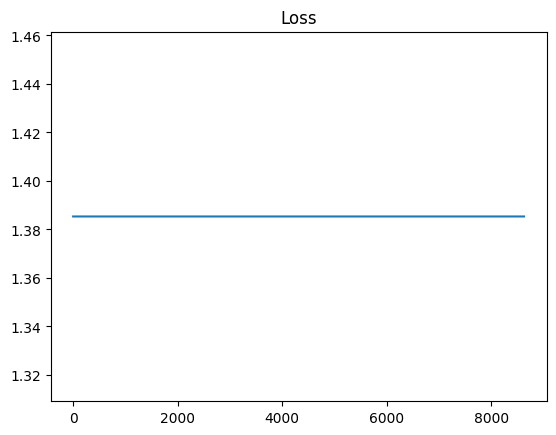

In [62]:
train(20000, checkpoints=5);

In [63]:
accuracy(transformer(eval_inp, single=False), eval_out), accuracy(transformer(train_inp, single=False), train_out)

(0.0, 0.0)

In [64]:
outputs = transformer(eval_inp, verbose=1, get=True, single=True)
att, att_val = transformer.get_attention()


Transformer Input =>
tensor([[[[0.1492],
          [0.1502],
          [0.1512],
          ...,
          [0.1773],
          [0.1783],
          [0.1793]],

         [[0.8663],
          [0.8672],
          [0.8682],
          ...,
          [0.8944],
          [0.8953],
          [0.8963]],

         [[0.8178],
          [0.8188],
          [0.8198],
          ...,
          [0.8459],
          [0.8469],
          [0.8479]],

         ...,

         [[0.7926],
          [0.7936],
          [0.7946],
          ...,
          [0.8207],
          [0.8217],
          [0.8227]],

         [[0.9419],
          [0.9428],
          [0.9438],
          ...,
          [0.9700],
          [0.9709],
          [0.9719]],

         [[0.8304],
          [0.8314],
          [0.8324],
          ...,
          [0.8585],
          [0.8595],
          [0.8605]]]], device='cuda:0', dtype=torch.float64)
	dim = torch.Size([1, 10, 32, 1])

Embedded tensor =>
tensor([[[[-0.3569,  0.2702,  0.3371,  ..., -0.0

In [64]:
for i, att_head in enumerate(eval_out[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()


KeyboardInterrupt



In [ ]:
for i, att_head in enumerate(outputs[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

In [ ]:
for i, att_head in enumerate(eval_inp[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

In [ ]:
plot_attention(att, 0, 0, 3, False, size=(1080, 720));

In [ ]:
plot_attention(att, 0, -1, 3, True, size=(1080, 720));

In [ ]:
plt.imshow(torch.arange(10*10).view(10, 10), cmap='bone_r')
torch.arange(10*10).view(10, 10)